# Exploratory Data Analysis — UCI Human Activity Recognition Dataset

This notebook performs exploratory data analysis (EDA) on the raw
UCI Human Activity Recognition Using Smartphones dataset.

The main objectives are to:

- inspect the structure and dimensions of the sensor data,
- examine activity and subject distributions,
- verify data quality,
- analyse basic statistics of the sensor channels, and
- visualize representative sensor signals.

No model training or preprocessing transformations are performed in
this notebook. The purpose of the analysis is to understand the raw
dataset before developing the common preprocessing pipeline.

## 1. Library Imports and Dataset Location

The required Python libraries are imported for numerical computation,
data analysis, file handling and visualization.

The project and dataset paths are constructed dynamically so that the
notebook can locate the UCI HAR dataset when executed from the project
root or the `Preprocessing` directory.

In [ ]:
# File-system path handling
from pathlib import Path
# Numerical array processing
import numpy as np
# Tabular data analysis
import pandas as pd
# Data visualization
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()

# If notebook starts inside Preprocessing/, move to project root
if not (PROJECT_ROOT / "Data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "Data" / "UCI HAR Dataset"

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_DIR)
print("Dataset exists:", DATA_DIR.exists())

KeyboardInterrupt: 

## 2. Sensor Channels

The raw inertial dataset contains nine sensor channels. These include
three-axis body acceleration, three-axis body angular velocity measured
by the gyroscope, and three-axis total acceleration.

Each observation therefore contains measurements from nine signals
recorded over the same 128 time steps.

In [3]:
SIGNALS = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z"
]

## 3. Loading the Raw Inertial Signals

The UCI HAR dataset stores every inertial signal in a separate text
file. The following function loads all nine channels for either the
training or test partition and combines them into a single
three-dimensional NumPy array.

The files are initially combined with shape:

`(9, number_of_samples, 128)`

and are transposed into:

`(number_of_samples, 128, 9)`

This representation corresponds to samples × time steps × sensor
channels and is the format required by the sequence-based models used
later in the project.

In [ ]:
def load_signals(base_path, split):
    # Store each sensor channel before combining them
    signal_data = []
 # Load the nine signal files belonging to the requested split
    for signal in SIGNALS:
        file_path = (
            base_path
            / split
            / "Inertial Signals"
            / f"{signal}_{split}.txt"
        )

        signal_data.append(
            np.loadtxt(file_path)
        )

    # (9, samples, 128)
    #      ↓
    # (samples, 128, 9)
    return np.transpose(
        np.array(signal_data),
        (1, 2, 0)
    )

## 4. Loading the Original Train and Test Data

The raw inertial signals are loaded using the official UCI training and
test partitions. At this stage, no additional validation split or data
transformation is performed.

The dimensions are printed to confirm that the signals were loaded and
combined correctly.

In [5]:
X_train_original = load_signals(DATA_DIR, "train")
X_test_original = load_signals(DATA_DIR, "test")

print("Train:", X_train_original.shape)
print("Test:", X_test_original.shape)

Train: (7352, 128, 9)
Test: (2947, 128, 9)


## 5. Activity Labels

The activity labels associated with every sensor window are loaded from
the original UCI HAR files.

At this exploratory stage, the original UCI class identifiers
(1 through 6) are preserved. Conversion to zero-based labels is carried
out later in the preprocessing notebook.

In [6]:
y_train_original = np.loadtxt(
    DATA_DIR / "train" / "y_train.txt",
    dtype=int
)

y_test_original = np.loadtxt(
    DATA_DIR / "test" / "y_test.txt",
    dtype=int
)

### Activity Classes

The six target activities represented in the dataset are:

1. Walking
2. Walking Upstairs
3. Walking Downstairs
4. Sitting
5. Standing
6. Laying

These names are used when displaying distributions and visualizations
throughout the exploratory analysis.

In [7]:
ACTIVITY_NAMES = [
    "Walking",
    "Walking Upstairs",
    "Walking Downstairs",
    "Sitting",
    "Standing",
    "Laying"
]

## 6. Participant Information

Each activity window is associated with the participant who generated
it. Subject identifiers are loaded so that the distribution of
participants can be examined.

Subject information is particularly important for this project because
the later validation split is performed by participant rather than by
randomly separating individual windows.

In [8]:
subject_train_original = np.loadtxt(
    DATA_DIR / "train" / "subject_train.txt",
    dtype=int
)

subject_test_original = np.loadtxt(
    DATA_DIR / "test" / "subject_test.txt",
    dtype=int
)

### Official Train/Test Subject Separation

The unique participants contained in the official training and testing
partitions are inspected. This confirms that the original UCI dataset
already separates the official training and test subjects.

The official test partition will remain unchanged during model
development.

In [9]:
print("Training subjects:",
      np.unique(subject_train_original))

print("Testing subjects:",
      np.unique(subject_test_original))

Training subjects: [ 1  3  5  6  7  8 11 14 15 16 17 19 21 22 23 25 26 27 28 29 30]
Testing subjects: [ 2  4  9 10 12 13 18 20 24]


## 7. Data Quality Assessment

Before any preprocessing is applied, the raw sensor measurements are
checked for missing (`NaN`) and infinite values.

Neural networks cannot reliably train when invalid numerical values are
present. Therefore, this check determines whether missing-value
handling or additional cleaning is required.

In [10]:
print(
    "Train NaNs:",
    np.isnan(X_train_original).sum()
)

print(
    "Test NaNs:",
    np.isnan(X_test_original).sum()
)

print(
    "Train infinite values:",
    np.isinf(X_train_original).sum()
)

print(
    "Test infinite values:",
    np.isinf(X_test_original).sum()
)

Train NaNs: 0
Test NaNs: 0
Train infinite values: 0
Test infinite values: 0


### Observation

No NaN or infinite values were detected in either the original training
or test sensor arrays. Therefore, no missing-value imputation was
required for this dataset.

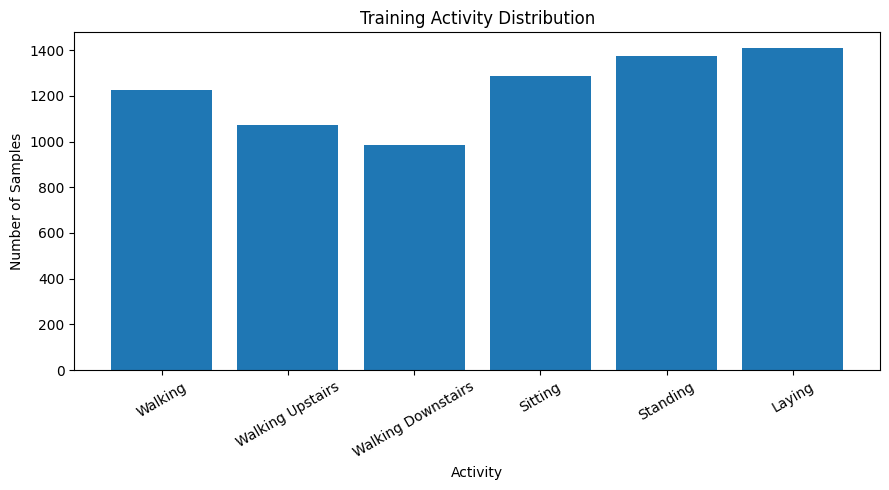

In [13]:
train_counts = pd.Series(
    y_train_original
).value_counts().sort_index()

plt.figure(figsize=(9, 5))

plt.bar(
    ACTIVITY_NAMES,
    train_counts.values
)

plt.title("Training Activity Distribution")
plt.xlabel("Activity")
plt.ylabel("Number of Samples")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

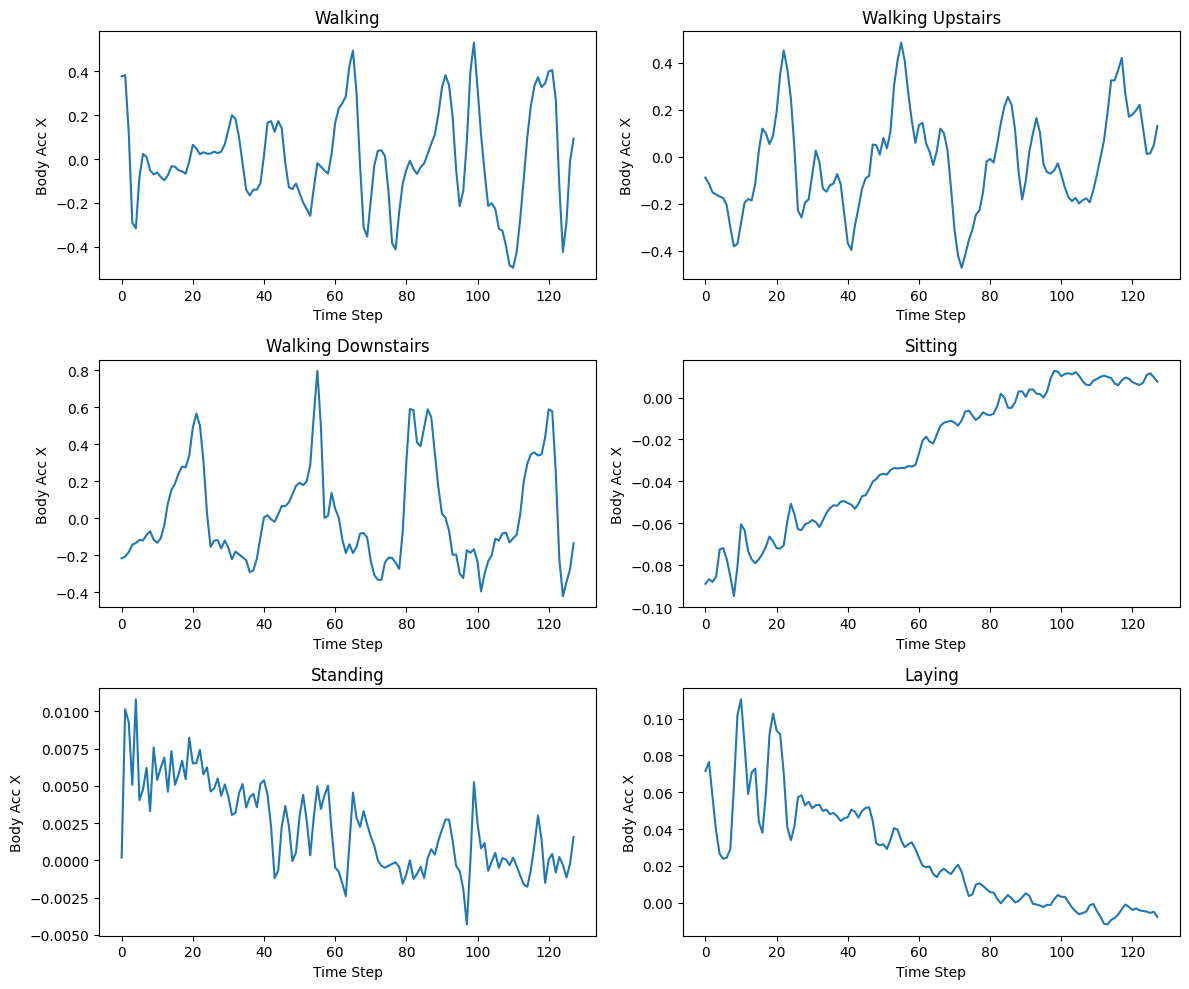

In [21]:
plt.figure(figsize=(12, 10))

for activity_id in range(1, 7):

    sample_index = np.where(
        y_train_original == activity_id
    )[0][0]

    plt.subplot(3, 2, activity_id)

    plt.plot(
        X_train_original[
            sample_index,
            :,
            0
        ]
    )

    plt.title(
        ACTIVITY_NAMES[
            activity_id - 1
        ]
    )

    plt.xlabel("Time Step")
    plt.ylabel("Body Acc X")

plt.tight_layout()
plt.show()

In [16]:
print("Training samples:", X_train_original.shape[0])
print("Testing samples:", X_test_original.shape[0])

print("Time steps per sample:", X_train_original.shape[1])
print("Sensor channels:", X_train_original.shape[2])

print(
    "Total samples:",
    X_train_original.shape[0]
    + X_test_original.shape[0]
)

print(
    "Total unique subjects:",
    len(
        np.unique(
            np.concatenate([
                subject_train_original,
                subject_test_original
            ])
        )
    )
)

print(
    "Number of activities:",
    len(ACTIVITY_NAMES)
)

Training samples: 7352
Testing samples: 2947
Time steps per sample: 128
Sensor channels: 9
Total samples: 10299
Total unique subjects: 30
Number of activities: 6


## 8. Activity Class Distribution

The number and percentage of observations belonging to each activity
are examined for both the original training and test partitions.

This analysis is important because a strongly imbalanced dataset could
make overall accuracy misleading. The class distribution also helps
justify the use of additional evaluation measures such as precision,
recall, macro F1-score and weighted F1-score.

In [17]:
def show_class_distribution(labels, split_name):
    counts = pd.Series(
        labels
    ).value_counts().sort_index()

    percentages = (
        counts / counts.sum() * 100
    )

    distribution = pd.DataFrame({
        "Activity": ACTIVITY_NAMES,
        "Count": counts.values,
        "Percentage": percentages.values
    })

    print(f"\n{split_name} distribution:")
    print(distribution)

    return distribution


train_distribution = show_class_distribution(
    y_train_original,
    "Training"
)

test_distribution = show_class_distribution(
    y_test_original,
    "Testing"
)


Training distribution:
             Activity  Count  Percentage
0             Walking   1226   16.675734
1    Walking Upstairs   1073   14.594668
2  Walking Downstairs    986   13.411317
3             Sitting   1286   17.491839
4            Standing   1374   18.688792
5              Laying   1407   19.137650

Testing distribution:
             Activity  Count  Percentage
0             Walking    496   16.830675
1    Walking Upstairs    471   15.982355
2  Walking Downstairs    420   14.251781
3             Sitting    491   16.661011
4            Standing    532   18.052257
5              Laying    537   18.221921


### Observation

All six activities are well represented in both partitions, although
the class frequencies are not exactly equal. Static activities such as
Standing and Laying contain slightly more samples than some dynamic
activities.

The imbalance is not extreme, but class-sensitive evaluation metrics
will be reported in addition to accuracy.

### Visual Comparison of Activity Frequencies

The following grouped bar chart compares the number of samples for each
activity in the original training and test partitions.

The visualization makes it easier to assess whether the overall class
composition is reasonably similar across the two official partitions.

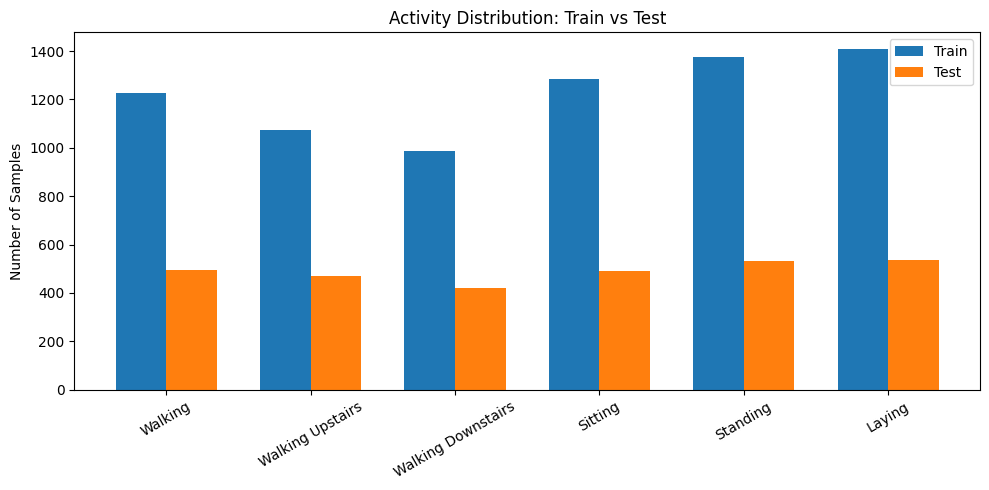

In [18]:
x = np.arange(
    len(ACTIVITY_NAMES)
)

width = 0.35

train_counts = np.array(
    [
        np.sum(y_train_original == i)
        for i in range(1, 7)
    ]
)

test_counts = np.array(
    [
        np.sum(y_test_original == i)
        for i in range(1, 7)
    ]
)

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    train_counts,
    width,
    label="Train"
)

plt.bar(
    x + width / 2,
    test_counts,
    width,
    label="Test"
)

plt.xticks(
    x,
    ACTIVITY_NAMES,
    rotation=30
)

plt.ylabel("Number of Samples")
plt.title(
    "Activity Distribution: Train vs Test"
)

plt.legend()
plt.tight_layout()
plt.show()

## 9. Number of Windows per Subject

The number of activity windows contributed by each participant is
examined to identify differences in subject-level sample counts.

Because multiple sensor windows originate from the same individual,
randomly dividing windows between training and validation sets could
allow subject-specific movement patterns to appear in both subsets.
This observation motivates the subject-wise validation strategy used
during preprocessing.

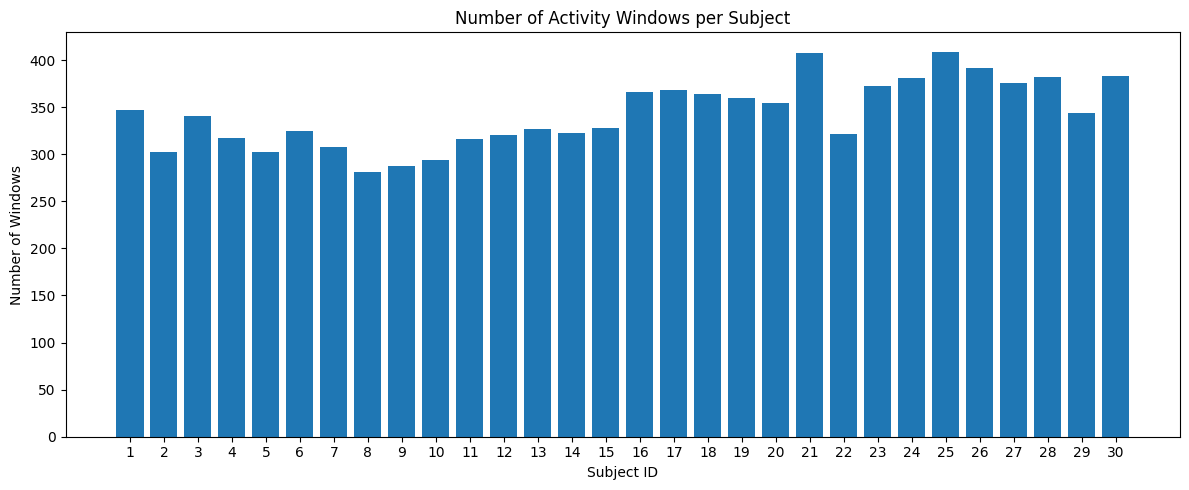

In [19]:
all_subjects = np.concatenate([
    subject_train_original,
    subject_test_original
])

subject_counts = pd.Series(
    all_subjects
).value_counts().sort_index()

plt.figure(figsize=(12, 5))

plt.bar(
    subject_counts.index.astype(str),
    subject_counts.values
)

plt.xlabel("Subject ID")
plt.ylabel("Number of Windows")
plt.title(
    "Number of Activity Windows per Subject"
)

plt.tight_layout()
plt.show()

### Observation

Participants contribute multiple activity windows to the dataset and
the exact number varies between subjects. Therefore, participant
identity must be considered when creating the validation partition.

A subject-wise split is used in the preprocessing stage so that data
from the same participant cannot occur in both training and validation
sets.

## 10. Sensor Channel Descriptive Statistics

Basic descriptive statistics are calculated for each of the nine raw
sensor channels.

The mean, standard deviation, minimum and maximum values provide an
overview of the numerical scale and variability of each signal. These
statistics are also useful for determining whether normalization is
appropriate before neural-network training.

In [20]:
channel_statistics = pd.DataFrame({
    "Signal": SIGNALS,
    "Mean": X_train_original.mean(
        axis=(0, 1)
    ),
    "Std": X_train_original.std(
        axis=(0, 1)
    ),
    "Min": X_train_original.min(
        axis=(0, 1)
    ),
    "Max": X_train_original.max(
        axis=(0, 1)
    )
})

channel_statistics

,Signal,Mean,Std,Min,Max
0,body_acc_x,-0.000636,0.194846,-1.232238,1.299912
1,body_acc_y,-0.000292,0.122427,-1.345267,0.975976
2,body_acc_z,-0.000275,0.106879,-1.364707,1.066916
3,body_gyro_x,0.000506,0.406815,-4.733656,4.155473
4,body_gyro_y,-0.000824,0.381854,-5.974330,5.746062
5,body_gyro_z,0.000113,0.255743,-2.763014,2.365982
6,total_acc_x,0.804749,0.414112,-0.466556,2.197618
7,total_acc_y,0.028755,0.390995,-1.582079,1.217350
8,total_acc_z,0.086498,0.357769,-1.639609,1.281363


### Observation

The sensor channels do not all have identical means, ranges or
variability. To provide the neural networks with consistently scaled
inputs, channel-wise standardization is therefore applied in the
preprocessing pipeline.

Importantly, the normalization parameters will be calculated using the
training partition only.

### Comparison Across Activity Classes

One representative sensor window from each activity class is visualized
using the same sensor channel. Using a common channel makes the temporal
differences between activities easier to compare.

The visualization is exploratory only; conclusions about model
performance are not drawn from individual example windows.